In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from   tensorflow import keras
from   tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from   tensorflow.keras.utils import load_img, img_to_array


# Carregar base de dados CIFAR-10

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ["avião", "automóvel", "pássaro", "gato", "cervo", "cachorro", "sapo", "cavalo", "navio", "caminhão"]

print(f"Formato de X_train: ", X_train.shape)
print(f"Formato de y_train: ", y_train.shape)
print(f"Formato de X_test: ", X_test.shape)
print(f"Formato de y_test: ", y_test.shape)   

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 318s 2us/step
Formato de X_train:  (50000, 32, 32, 3)
Formato de y_train:  (50000,)
Formato de X_test:  (10000, 32, 32, 3)
Formato de y_test:  (10000,)


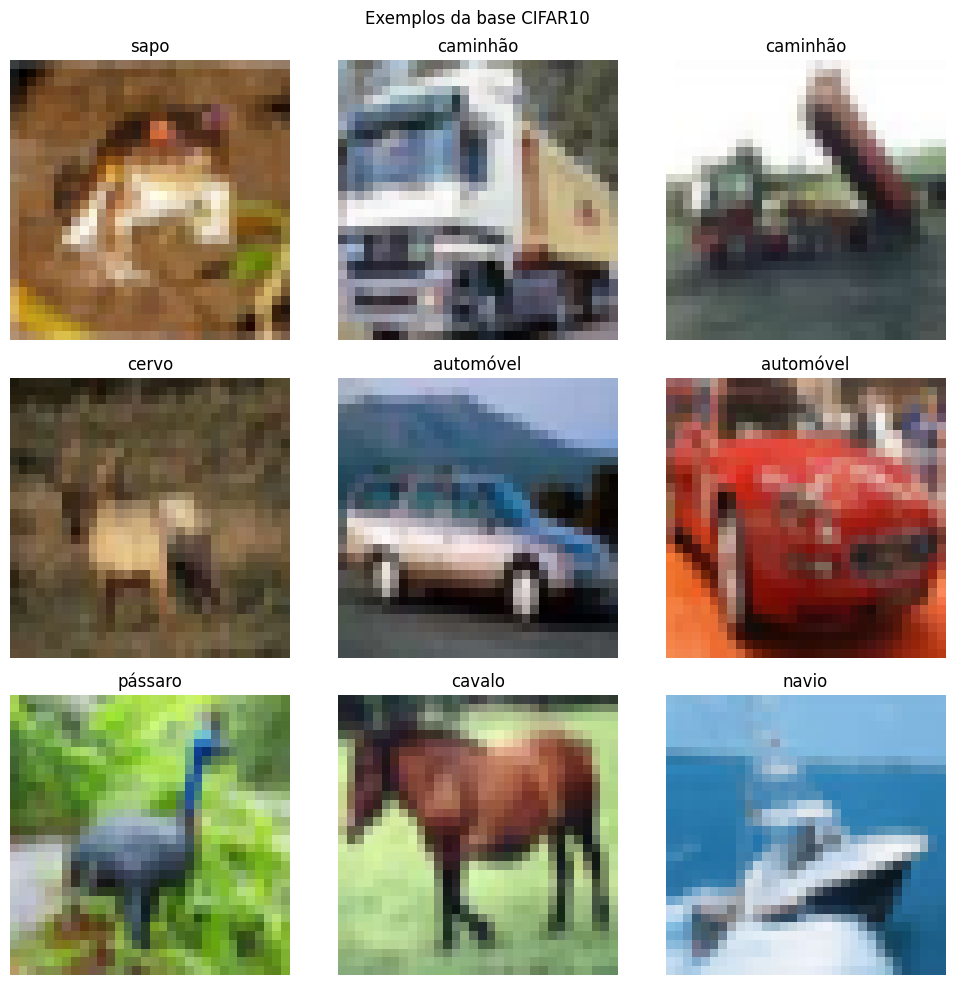

In [4]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.suptitle("Exemplos da base CIFAR10")
plt.tight_layout()
plt.show()

# Criação do modelo CNN

In [5]:
model = keras.Sequential()

model.add(Input(shape=(32, 32, 3)))

model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Treinar a rede

In [6]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 55ms/step - accuracy: 0.4115 - loss: 1.6041 - val_accuracy: 0.5144 - val_loss: 1.3579
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.5491 - loss: 1.2545 - val_accuracy: 0.5831 - val_loss: 1.1759
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.6077 - loss: 1.1051 - val_accuracy: 0.6204 - val_loss: 1.0933
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6484 - loss: 0.9967 - val_accuracy: 0.6157 - val_loss: 1.0861
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.6783 - loss: 0.9137 - val_accuracy: 0.6576 - val_loss: 0.9750
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.7003 - loss: 0.8570 - val_accuracy: 0.6571 - val_loss: 0.9716
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.7207 - loss: 0.7918 - val_accuracy: 0.6887 - val_loss: 0.8905
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7426 - loss: 0.7330 - 

# Plot da Acurácia e Loss

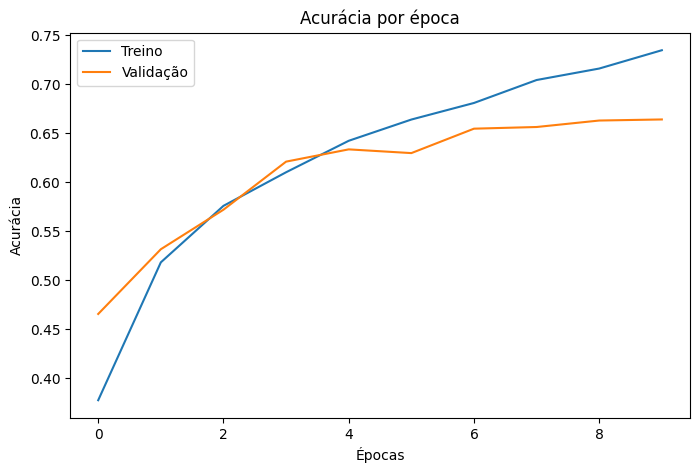

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label="Treino")
plt.plot(history.history['val_accuracy'], label="Validação")
plt.title("Acurácia por época")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.show()

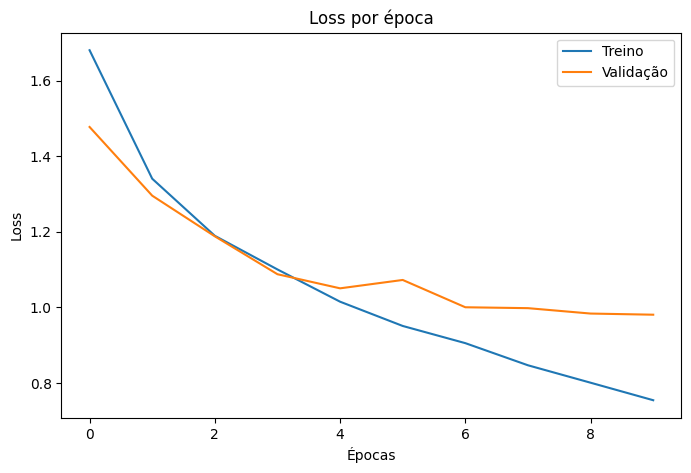

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Treino")
plt.plot(history.history['val_loss'], label="Validação")
plt.title("Loss por época")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Realizando predições

In [3]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Acurácia no conjunto de teste: {test_acc:.2}")
print(f"Loss no test: {test_loss:.4f}")

NameError: name 'model' is not defined

# Previsão em imagens do teste

In [ ]:
pred_probs = model.predict(X_test[:9])
pred_labels = np.argmax(pred_probs, axis=1)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[i])
    real = class_names[y_test[i]]
    pred = class_names[pred_labels[i]]
    plt.title(f"Real: {real}\nPredição: {pred}")
    plt.axis('off')
plt.suptitle("Previsões em imagens do conjunto de teste")
plt.tight_layout()
plt.show()